In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np
import math
import pandas as pd

Input the network configuration

In [2]:
AM_Matrix = []
LG_Matrix = []
f0_Matrix = []
inputfile = open('/Users/rl884/Downloads/PICIN/Result/BetaTest_G8_Result_f0.txt','r')
for line in inputfile:
    line_split = line.replace('\n','').split('\t')
    if line_split[0] == 'Adjacency Matrix:':
        AM_Matrix.append(line_split[-1])
    elif line_split[0] == 'Logic Gate:':
        LG_Matrix.append(line_split[-1])
    elif line_split[0] == 'f0:':
        f0_Matrix.append(eval(line_split[-1]))
inputfile.close()

GeneNames = [str(i) for i in range(1, 1+len(f0_Matrix[0]))]

def Remove_nonsense_1_in_LG(AM_i, LG_i):
    NumOfGenes = int(len(LG_i)/2)
    TF_ind = []
    LG_output = ''
    for i in range(0, NumOfGenes):
        TF_ind.append([])
        for each_ind in [i+NumOfGenes*j for j in range(0, NumOfGenes)]:
            TF_ind[-1].append(AM_i[each_ind])
    
    for i in range(0, NumOfGenes):
        if LG_i[2*i] == '1':
            if TF_ind[i].count('1') <= 1:
                LG_output = LG_output + '0'
            else:
                LG_output = LG_output + LG_i[2*i]
        else:
            LG_output = LG_output + '0'

        if LG_i[2*i+1] == '1':
            if TF_ind[i].count('2') <= 1:
                LG_output = LG_output + '0'
            else:
                LG_output = LG_output + LG_i[2*i+1]
        else:
            LG_output = LG_output + '0'
    
    return LG_output

Network Visualization

In [3]:
from pyvis import network as net
from pyvis.network import Network
import networkx as nx

def Network_Visualization(AM_, LG_, f0_, GeneNames_):
    NumOfGenes = len(f0_)
    g=net.Network(height='100%', width='100%', bgcolor='#ffffff', # Changed height
                    font_color='black', notebook = True, directed=True, cdn_resources='remote')

    for i in range(0, NumOfGenes):
        g.add_node(i, label=GeneNames_[i], value=10, color = '#%02x%02x%02x' % (int(255*(1-f0_[i])), int(255*(1-f0_[i])), int(255*(1-f0_[i]))))

    for i in range(0, len(AM_)):
        if AM_[i] == '0':
            pass
        elif AM_[i] == '1':
            if LG_[2*(i%NumOfGenes)] == '0':
                g.add_edge(i//NumOfGenes, i%NumOfGenes, weight=1, color='green', arrowStrikethrough=True)
            else:
                g.add_edge(i//NumOfGenes, i%NumOfGenes, weight=1, color='green', dashes=True, arrowStrikethrough=True)
        elif AM_[i] == '2':
            if LG_[1+2*(i%NumOfGenes)] == '0':
                g.add_edge(i//NumOfGenes, i%NumOfGenes, weight=1, color='red', arrowStrikethrough=True)
            else:
                g.add_edge(i//NumOfGenes, i%NumOfGenes, weight=1, color='red', dashes=True, arrowStrikethrough=True)
    
    g.save_graph('test.html')
    return

In [84]:
Network_Visualization(AM_Matrix[18], Remove_nonsense_1_in_LG(AM_Matrix[18], LG_Matrix[18]), f0_Matrix[18], GeneNames)

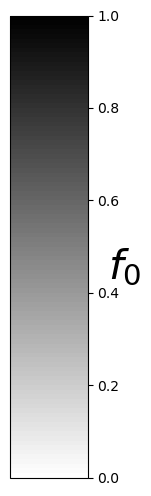

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the colormap
colors = [(1, 1, 1), (0, 0, 0)]  # (255, 255, 255) to (0, 255, 255)
n_bins = 100  # Number of bins in the colormap
cmap_name = "my_colormap"
my_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Create a color bar legend (vertical)
fig, ax = plt.subplots(figsize=(1, 6))
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=my_cmap), cax=ax, orientation='vertical')
cbar.set_label('$f_{0}$', fontsize=30, rotation=360)

# Display the plot
plt.show()


Undirected network

In [4]:
from pyvis import network as net
from pyvis.network import Network
import networkx as nx

def Network_Visualization(AM_, GeneNames_):
    NumOfGenes = len(AM_)
    g=net.Network(height='100%', width='100%', bgcolor='#ffffff', # Changed height
                    font_color='black', notebook = True, directed=True, cdn_resources='remote')

    for i in range(0, NumOfGenes):
        g.add_node(i, label=GeneNames_[i], value=10)
        
    for i in range(0, NumOfGenes):
        for j in range(0, NumOfGenes):
            if AM_.iloc[i,j] == 0:
                pass
            elif AM_.iloc[i,j] == 1:
                g.add_edge(i, j, weight=1, arrowStrikethrough=True)
    
    g.save_graph('test.html')
    return

In [6]:
inputfile = pd.read_excel('/Users/rl884/Downloads/2021-Rossi_Nature-master/04_ChExMix_Peaks/ssTFs_ChIP.xlsx', index_col=0)
Network_Visualization(inputfile, inputfile.index.to_list())